# Barcode 17 vs. barcode 18 DMR analysis

This notebook demonstrates the DMR workflow on the CTCF demo barcode BAMs:

- `barcode17`: targeted methylation experiment
- `barcode18`: control

The workflow is intentionally top-to-bottom and reproducible: make bedMethyl pileups, run pairwise regional DMR tests, inspect single-site statistics, run the multi-sample wrapper, and visualize the strongest differential methylation calls.


## What this notebook is testing

`dimelo.dmr` wraps native `modkit dmr` commands. Those commands operate on bgzipped, tabix-indexed bedMethyl pileups, so the first section converts the two BAMs into A-modification pileups with `parse_bam.pileup()`.

For this small demo we use one CTCF locus on `chr16` where the barcode17 and barcode18 coverages are closer than the chr14 example. Running the whole example BED can be much slower and, with this modkit/reference combination, may emit repeated invalid-reference-coordinate messages during motif-filtered pileup. The region variable below is the one place to expand the analysis once the reference/BAM pair is confirmed for a larger run.


In [3]:
from __future__ import annotations

import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dimelo import dmr, parse_bam, run_modkit

# Reload local modules when developing this notebook against an editable checkout.
dmr = importlib.reload(dmr)
parse_bam = importlib.reload(parse_bam)
run_modkit = importlib.reload(run_modkit)
run_modkit._get_modkit_capabilities_cached.cache_clear()

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})


In [4]:
DATA_DIR = Path("dimelo/test/data")
OUT_DIR = Path("artifacts/dmr_barcode17_vs_18_notebook")
OUT_DIR.mkdir(parents=True, exist_ok=True)

barcode17_bam = DATA_DIR / "barcode17.merged.sorted.ctcf_demo.sorted.bam"
barcode18_bam = DATA_DIR / "barcode18.merged.sorted.ctcf_demo.sorted.bam"
ref_genome = Path("dimelo/test/output/chm13.draft_v1.0.fasta")
source_regions_bed = DATA_DIR / "ctcf_demo_peak_and_not_peak.sorted.merged.bed"

analysis_region = "chr16:63442391-63446452"
analysis_chrom, region_span = analysis_region.split(":")
analysis_start, analysis_end = [int(x) for x in region_span.split("-")]
region_bed = OUT_DIR / "chr16_ctcf_demo_regions.bed"

required = [barcode17_bam, barcode17_bam.with_suffix(barcode17_bam.suffix + ".bai"), barcode18_bam, barcode18_bam.with_suffix(barcode18_bam.suffix + ".bai"), ref_genome, ref_genome.with_suffix(ref_genome.suffix + ".fai"), source_regions_bed]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required demo inputs:" + chr(10) + chr(10).join(missing))

caps = run_modkit.get_modkit_capabilities()
print(caps.version_raw)
print(f"Outputs: {OUT_DIR.resolve()}")


modkit 0.6.1
Outputs: /Users/ngamarra/Documents/GitHub/dimelo-toolkit/artifacts/dmr_barcode17_vs_18_notebook


## Build a compact region set

The regional DMR call uses BED intervals. Here we keep intervals from the demo BED that lie inside the selected `chr16` span. This locus has three intervals with more comparable coverage between barcode17 and barcode18 than the original chr14 slice, which makes the regional example easier to interpret.


In [6]:
source_regions = pd.read_csv(source_regions_bed, sep="	", header=None, comment="#")
source_regions = source_regions.rename(columns={0: "chrom", 1: "start", 2: "end"})
region_table = source_regions.loc[
    (source_regions["chrom"] == analysis_chrom)
    & (source_regions["start"] >= analysis_start)
    & (source_regions["end"] <= analysis_end),
    ["chrom", "start", "end"],
].drop_duplicates().sort_values(["chrom", "start", "end"]).reset_index(drop=True)

if region_table.empty:
    raise ValueError(f"No source regions found within {analysis_region}.")

region_table.to_csv(region_bed, sep="	", header=False, index=False)
display(region_table)
print(region_bed)


artifacts/dmr_barcode17_vs_18_notebook/chr16_ctcf_demo_regions.bed


,chrom,start,end
0,chr16,63442391,63442541
1,chr16,63444241,63444602
2,chr16,63446302,63446452


## Create bedMethyl pileups from each BAM

The targeted sample is barcode17 and the control sample is barcode18. We pile up A modifications with an explicit ML threshold. `override_checks=True` is set because the first-read alignment-quality heuristic is conservative for these small demo subsets; the region-specific pileup itself is restricted to the valid locus above.


In [8]:
ML_THRESHOLD = 0.5
THREADS = 2

samples = {
    "barcode17_targeted": barcode17_bam,
    "barcode18_control": barcode18_bam,
}

pileups: dict[str, Path] = {}
processed_region_beds: dict[str, Path] = {}
for sample_id, bam_path in samples.items():
    pileup_path, processed_regions = parse_bam.pileup(
        bam_path,
        output_name=f"{sample_id}_chr16_A",
        output_directory=OUT_DIR,
        ref_genome=ref_genome,
        regions=[analysis_region],
        motifs=["A,0"],
        thresh=ML_THRESHOLD,
        cores=THREADS,
        log=False,
        cleanup=True,
        overwrite=False,
        quiet=True,
        override_checks=True,
    )
    pileups[sample_id] = pileup_path
    processed_region_beds[sample_id] = processed_regions

pd.DataFrame(
    {
        "sample_id": list(pileups),
        "role": ["targeted experiment", "control"],
        "bam": [str(samples[s]) for s in pileups],
        "pileup": [str(pileups[s]) for s in pileups],
        "tabix_index_exists": [pileups[s].with_suffix(pileups[s].suffix + ".tbi").exists() for s in pileups],
    }
)


,sample_id,role,bam,pileup,tabix_index_exists
0,barcode17_targeted,targeted experiment,dimelo/test/data/barcode17.merged.sorted.ctcf_demo.sorted.bam,artifacts/dmr_barcode17_vs_18_notebook/barcode17_targeted_chr16_A/pileup.sorted.bed.gz,True
1,barcode18_control,control,dimelo/test/data/barcode18.merged.sorted.ctcf_demo.sorted.bam,artifacts/dmr_barcode17_vs_18_notebook/barcode18_control_chr16_A/pileup.sorted.bed.gz,True


## Quick pileup QC

These summaries check that both samples have usable coverage and expose the methylation fraction distribution before any statistical comparison. `mod_fraction` is the pileup modified fraction per genomic A site.


In [10]:
def read_bedmethyl(path: Path) -> pd.DataFrame:
    table = pd.read_csv(path, sep="	", comment="#", header=None)
    cols = [
        "chrom", "start", "end", "name", "score", "strand", "thick_start", "thick_end",
        "color", "valid_coverage", "fraction_modified", "n_mod", "n_canonical",
        "n_other_mod", "n_delete", "n_fail", "n_diff", "n_nocall",
    ]
    table = table.iloc[:, : min(table.shape[1], len(cols))]
    table.columns = cols[: table.shape[1]]
    for col in ["start", "end", "valid_coverage", "fraction_modified", "n_mod", "n_canonical"]:
        if col in table.columns:
            table[col] = pd.to_numeric(table[col], errors="coerce")
    if {"n_mod", "valid_coverage"}.issubset(table.columns):
        table["mod_fraction"] = table["n_mod"] / table["valid_coverage"].replace(0, np.nan)
    elif "fraction_modified" in table.columns:
        table["mod_fraction"] = table["fraction_modified"] / 100.0
    return table

pileup_tables = []
for sample_id, pileup_path in pileups.items():
    table = read_bedmethyl(pileup_path)
    table["sample_id"] = sample_id
    pileup_tables.append(table)

pileup_df = pd.concat(pileup_tables, ignore_index=True)
qc = (
    pileup_df.groupby("sample_id")
    .agg(
        n_sites=("start", "size"),
        median_valid_coverage=("valid_coverage", "median"),
        mean_valid_coverage=("valid_coverage", "mean"),
        mean_mod_fraction=("mod_fraction", "mean"),
        max_mod_fraction=("mod_fraction", "max"),
    )
    .reset_index()
)
display(qc)


,sample_id,n_sites,median_valid_coverage,mean_valid_coverage,mean_mod_fraction,max_mod_fraction
0,barcode17_targeted,1086,13.0,11.222836,0.072207,1.0
1,barcode18_control,972,8.0,7.897119,0.044248,1.0


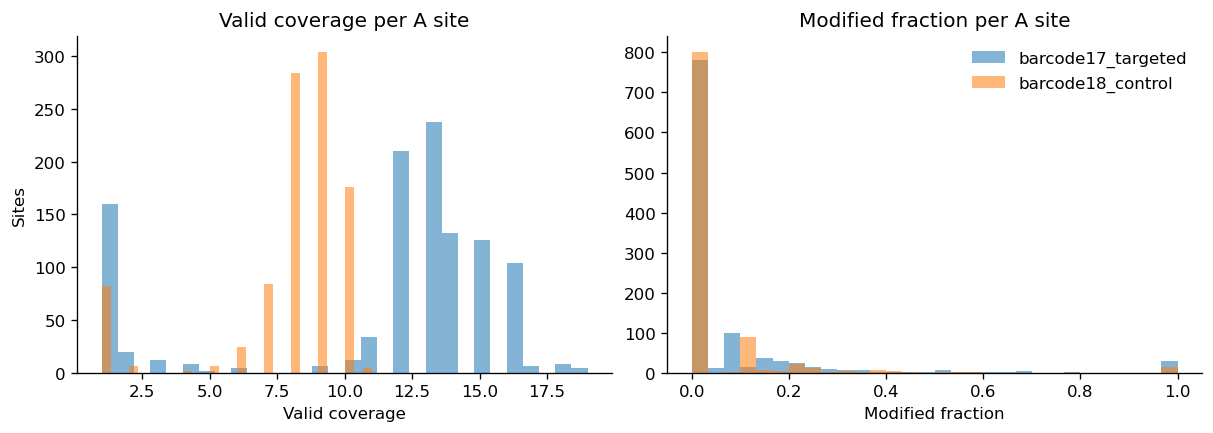

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
for sample_id, group in pileup_df.groupby("sample_id"):
    axes[0].hist(group["valid_coverage"].dropna(), bins=30, alpha=0.55, label=sample_id)
    axes[1].hist(group["mod_fraction"].dropna(), bins=30, alpha=0.55, label=sample_id)
axes[0].set_title("Valid coverage per A site")
axes[0].set_xlabel("Valid coverage")
axes[0].set_ylabel("Sites")
axes[1].set_title("Modified fraction per A site")
axes[1].set_xlabel("Modified fraction")
axes[1].legend(frameon=False)
plt.show()


## Regional DMR: control vs targeted experiment

This is the main defined-region DMR call. Barcode18 is passed as control (`-a`) and barcode17 is passed as experiment (`-b`). For regional output, modkit reports effect size and Cohen's h confidence intervals. The notebook flags candidate DMRs when the confidence interval excludes zero and the absolute effect is at least the chosen threshold.


In [13]:
ABS_EFFECT_MIN = 0.03

regional_result = dmr.run_dmr_pair(
    control_bed_methyl=pileups["barcode18_control"],
    experiment_bed_methyl=pileups["barcode17_targeted"],
    ref_genome=ref_genome,
    out_path=OUT_DIR / "barcode17_targeted_vs_barcode18_control.A.regional.bed",
    regions_bed=region_bed,
    bases=["A"],
    min_valid_coverage=1,
    threads=THREADS,
    pvalue_max=0.05,
    abs_effect_size_min=ABS_EFFECT_MIN,
)

regional = regional_result.sites.copy()
regional["ci_excludes_zero"] = (regional["cohen_h_low"] > 0) | (regional["cohen_h_high"] < 0)
regional["candidate_dmr"] = regional["ci_excludes_zero"] & (regional["effect_size"].abs() >= ABS_EFFECT_MIN)
regional["direction"] = np.where(regional["effect_size"] > 0, "barcode17 higher", "barcode18 higher")
regional = regional.sort_values(["candidate_dmr", "score"], ascending=[False, False]).reset_index(drop=True)

display(
    regional[
        [
            "chrom", "start", "end", "score", "a_pct_modified", "b_pct_modified",
            "effect_size", "cohen_h", "cohen_h_low", "cohen_h_high",
            "direction", "candidate_dmr",
        ]
    ]
)
print("Candidate DMRs:", int(regional["candidate_dmr"].sum()))


Candidate DMRs: 1


,chrom,start,end,score,a_pct_modified,b_pct_modified,effect_size,cohen_h,cohen_h_low,cohen_h_high,direction,candidate_dmr
0,chr16,63442391,63442541,5.830600,0.062857,0.173913,0.111056,0.353514,0.160810,0.546218,barcode17 higher,True
1,chr16,63444241,63444602,1.132599,0.237668,0.302083,0.064415,0.145345,-0.019670,0.310360,barcode17 higher,False
2,chr16,63446302,63446452,0.136121,0.137615,0.182390,0.044775,0.122408,-0.121319,0.366135,barcode17 higher,False


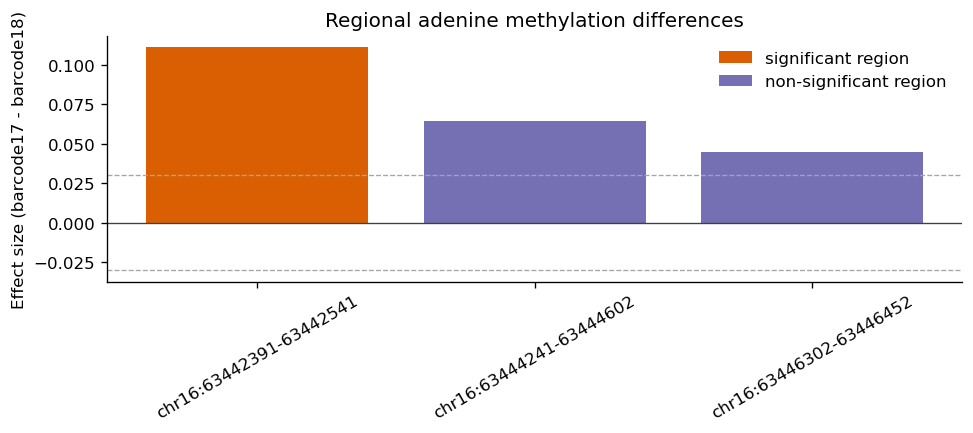

In [14]:
from matplotlib.patches import Patch

plot_table = regional.sort_values("start")
labels = plot_table["chrom"] + ":" + plot_table["start"].astype(str) + "-" + plot_table["end"].astype(str)
colors = np.where(plot_table["candidate_dmr"], "#D95F02", "#7570B3")

fig, ax = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
ax.bar(labels, plot_table["effect_size"], color=colors)
ax.axhline(0, color="0.25", linewidth=0.8)
ax.axhline(ABS_EFFECT_MIN, color="0.65", linewidth=0.8, linestyle="--")
ax.axhline(-ABS_EFFECT_MIN, color="0.65", linewidth=0.8, linestyle="--")
ax.set_ylabel("Effect size (barcode17 - barcode18)")
ax.set_title("Regional adenine methylation differences")
ax.tick_params(axis="x", rotation=30)
legend_handles = [
    Patch(facecolor="#D95F02", label="significant region"),
    Patch(facecolor="#7570B3", label="non-significant region"),
]
ax.legend(handles=legend_handles, frameon=False, loc="upper right")
plt.show()


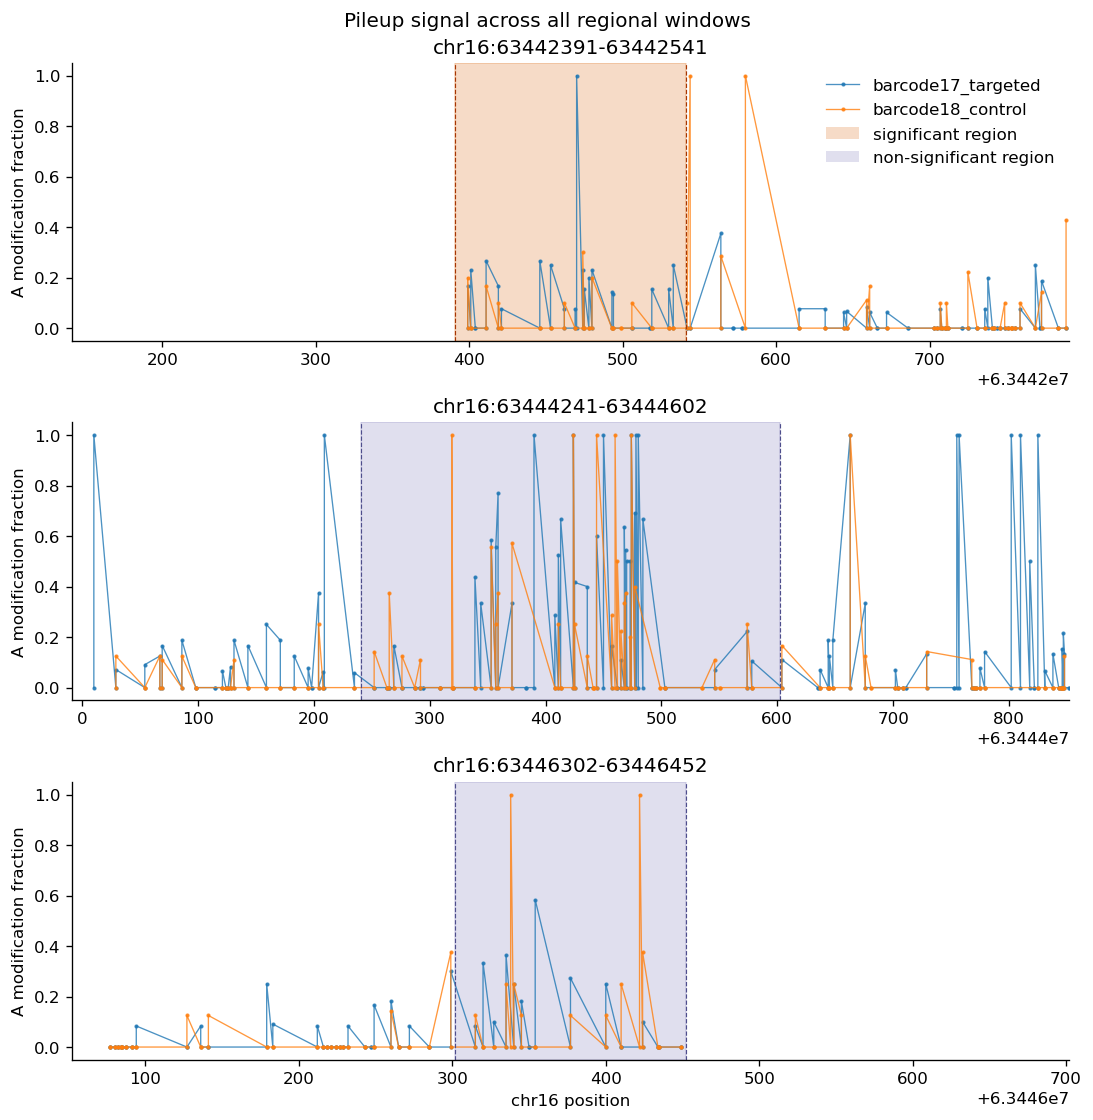

In [ ]:
from matplotlib.patches import Patch

region_lookup = regional.set_index(["chrom", "start", "end"])
plot_flank = 250
fig, axes = plt.subplots(
    nrows=len(region_table),
    ncols=1,
    figsize=(9, 3.0 * len(region_table)),
    constrained_layout=True,
    sharey=True,
)
if len(region_table) == 1:
    axes = [axes]

for ax, region in zip(axes, region_table.itertuples(index=False), strict=False):
    window_start = max(0, int(region.start) - plot_flank)
    window_end = int(region.end) + plot_flank
    for sample_id, group in pileup_df.groupby("sample_id"):
        ordered = group.sort_values("start")
        window = ordered[(ordered["start"] >= window_start) & (ordered["start"] <= window_end)]
        ax.plot(
            window["start"],
            window["mod_fraction"],
            marker=".",
            linewidth=0.8,
            markersize=3,
            alpha=0.8,
            label=sample_id,
        )

    region_key = (region.chrom, int(region.start), int(region.end))
    region_row = region_lookup.loc[[region_key]].iloc[0] if region_key in region_lookup.index else None
    is_significant = region_row is not None and bool(region_row["candidate_dmr"])
    region_label = "significant region" if is_significant else "non-significant region"
    region_fill = "#D95F02" if is_significant else "#7570B3"
    region_line = "#A63603" if is_significant else "#4E4E8C"
    ax.axvspan(int(region.start), int(region.end), color=region_fill, alpha=0.22)
    ax.axvline(int(region.start), color=region_line, linewidth=0.7, linestyle="--")
    ax.axvline(int(region.end), color=region_line, linewidth=0.7, linestyle="--")
    ax.set_xlim(window_start, window_end)
    ax.set_ylabel("A modification fraction")
    ax.set_title(f"{region.chrom}:{region.start}-{region.end}")

sample_handles, sample_labels = axes[0].get_legend_handles_labels()
sample_unique = dict(zip(sample_labels, sample_handles))
region_handles = [
    Patch(facecolor="#D95F02", alpha=0.22, label="significant region"),
    Patch(facecolor="#7570B3", alpha=0.22, label="non-significant region"),
]
axes[0].legend(list(sample_unique.values()) + region_handles, list(sample_unique.keys()) + [h.get_label() for h in region_handles], frameon=False, loc="upper right")
axes[-1].set_xlabel(f"{analysis_chrom} position")
fig.suptitle("Pileup signal across all regional windows", y=1.02)
plt.show()


## 100 bp sliding-window discovery

This section scans the selected chr16 demo locus with overlapping 100 bp windows and runs the same pairwise DMR test on each window. The current demo pileups are locus-restricted, so this is a practical discovery pass over the analyzed region rather than a full-genome scan. To make it genome-wide, regenerate the pileups without the narrow `regions` filter and reuse the same sliding-window logic.


> reading reference FASTA at "/Users/ngamarra/Documents/GitHub/dimelo-toolkit/dimelo/test/output/chm13.draft_v1.0.fasta"
> 1 common sequence(s) between FASTA and both samples
> loaded 17 regions
> loading 3 regions at a time
> checking for regions contained in samples
> 17 regions processed successfully and 0 regions failed


,chrom,start,end,score,a_pct_modified,b_pct_modified,effect_size,cohen_h,cohen_h_low,cohen_h_high,direction,candidate_dmr
0,chr16,63444641,63444891,7.332527,0.024390,0.109827,0.085436,0.361945,0.189198,0.534691,barcode17 higher,True
1,chr16,63442391,63442641,4.715366,0.074766,0.166667,0.091900,0.287145,0.113182,0.461108,barcode17 higher,True
2,chr16,63445391,63445641,4.625132,0.019048,0.078616,0.059569,0.291482,0.117205,0.465760,barcode17 higher,True
3,chr16,63443391,63443641,2.967453,0.075862,0.135021,0.059159,0.194461,0.048342,0.340580,barcode17 higher,True
4,chr16,63446141,63446391,2.623913,0.063415,0.128289,0.064875,0.223499,0.046369,0.400630,barcode17 higher,True
5,chr16,63442891,63443141,2.092976,0.059925,0.108586,0.048661,0.176979,0.021776,0.332183,barcode17 higher,True
6,chr16,63444391,63444641,1.962464,0.237410,0.341772,0.104362,0.230936,0.021543,0.440328,barcode17 higher,True
7,chr16,63443141,63443391,1.497088,0.049180,0.089239,0.040059,0.159469,-0.001236,0.320175,barcode17 higher,False
8,chr16,63444891,63445141,1.074999,0.045662,0.081006,0.035343,0.146514,-0.021626,0.314655,barcode17 higher,False
9,chr16,63446391,63446452,0.902033,0.148936,0.059701,-0.089235,-0.298739,-0.074179,0.671658,barcode18 higher,False


Candidate 100 bp bins: 7


,bin_group,chrom,start,end,n_bins,max_score,max_effect_size
0,3,chr16,63444141,63445141,4,7.332527,0.104362
1,1,chr16,63442391,63442641,1,4.715366,0.091900
2,5,chr16,63446141,63446391,1,2.623913,0.064875


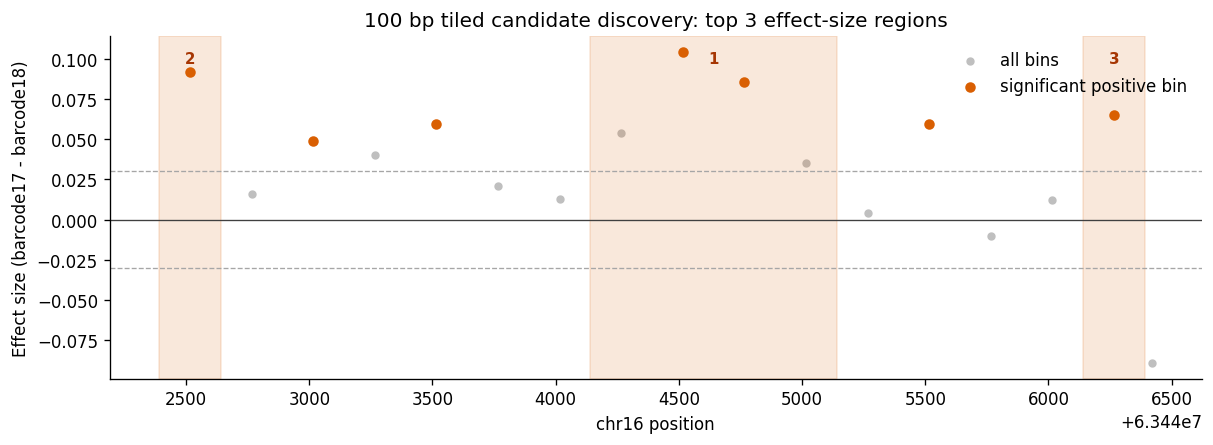

In [37]:
DISCOVERY_WINDOW_BP = 100
DISCOVERY_STEP_BP = 25
tiled_region_bed = OUT_DIR / "chr16_100bp_windows.bed"
tiled_region_output = OUT_DIR / "barcode17_targeted_vs_barcode18_control.A.sliding_100bp.bed"

tiled_regions = pd.DataFrame(
    {
        "chrom": analysis_chrom,
        "start": np.arange(analysis_start, analysis_end - DISCOVERY_WINDOW_BP + 1, DISCOVERY_STEP_BP, dtype=int),
    }
)
tiled_regions["end"] = np.minimum(
    tiled_regions["start"] + DISCOVERY_WINDOW_BP,
    analysis_end,
).astype(int)
tiled_regions = tiled_regions[["chrom", "start", "end"]].copy()
tiled_regions.to_csv(tiled_region_bed, sep="\t", header=False, index=False)

tiled_result = dmr.run_dmr_pair(
    control_bed_methyl=pileups["barcode18_control"],
    experiment_bed_methyl=pileups["barcode17_targeted"],
    ref_genome=ref_genome,
    out_path=tiled_region_output,
    regions_bed=tiled_region_bed,
    bases=["A"],
    min_valid_coverage=1,
    threads=THREADS,
    pvalue_max=0.05,
    abs_effect_size_min=ABS_EFFECT_MIN,
)

tiled = tiled_result.sites.copy()
tiled["ci_excludes_zero"] = (tiled["cohen_h_low"] > 0) | (tiled["cohen_h_high"] < 0)
tiled["candidate_dmr"] = tiled["ci_excludes_zero"] & (tiled["effect_size"] >= ABS_EFFECT_MIN)
tiled["direction"] = np.where(tiled["effect_size"] > 0, "barcode17 higher", "barcode18 higher")
tiled = tiled.sort_values(["candidate_dmr", "score"], ascending=[False, False]).reset_index(drop=True)
tiled["midpoint"] = (tiled["start"] + tiled["end"]) / 2.0

candidate_regions = tiled.loc[tiled["candidate_dmr"]].sort_values(["chrom", "start", "end"]).copy()
if not candidate_regions.empty:
    candidate_regions["window_group"] = candidate_regions["start"].diff().ne(DISCOVERY_STEP_BP).cumsum()
    candidate_regions = candidate_regions.groupby("window_group", as_index=False).agg(
        chrom=("chrom", "first"),
        start=("start", "min"),
        end=("end", "max"),
        n_bins=("start", "size"),
        max_score=("score", "max"),
        max_effect_size=("effect_size", "max"),
    )
    candidate_regions = candidate_regions.sort_values("max_effect_size", ascending=False).reset_index(drop=True)
else:
    candidate_regions = pd.DataFrame(
        columns=["chrom", "start", "end", "n_bins", "max_score", "max_effect_size"]
    )

top_candidate_regions = candidate_regions.head(3).copy()

display(
    tiled[
        [
            "chrom", "start", "end", "score", "a_pct_modified", "b_pct_modified",
            "effect_size", "cohen_h", "cohen_h_low", "cohen_h_high",
            "direction", "candidate_dmr",
        ]
    ]
)
print("Candidate 100 bp windows:", int(tiled["candidate_dmr"].sum()))
display(top_candidate_regions)

fig, ax = plt.subplots(figsize=(10, 3.6), constrained_layout=True)
ax.axhline(0, color="0.25", linewidth=0.8)
ax.axhline(ABS_EFFECT_MIN, color="0.65", linewidth=0.8, linestyle="--")
ax.axhline(-ABS_EFFECT_MIN, color="0.65", linewidth=0.8, linestyle="--")
ax.scatter(
    tiled["midpoint"],
    tiled["effect_size"],
    color="0.75",
    s=16,
    zorder=1,
    label="all bins",
)
ax.scatter(
    tiled.loc[tiled["candidate_dmr"], "midpoint"],
    tiled.loc[tiled["candidate_dmr"], "effect_size"],
    color="#D95F02",
    s=28,
    label="significant positive bin",
    zorder=3,
)
for rank, row in enumerate(top_candidate_regions.itertuples(index=False), start=1):
    ax.axvspan(row.start, row.end, color="#D95F02", alpha=0.14)
    ax.text(
        (row.start + row.end) / 2.0,
        ax.get_ylim()[1] * 0.92,
        str(rank),
        ha="center",
        va="top",
        fontsize=9,
        color="#A63603",
        fontweight="bold",
        zorder=4,
    )
ax.set_xlabel(f"{analysis_chrom} position")
ax.set_ylabel("Effect size (barcode17 - barcode18)")
ax.set_title("100 bp sliding-window candidate discovery: top 3 significant effect-size regions")
ax.legend(frameon=False, loc="upper right")
plt.show()


## Zoomed top regions and CTCF motif check

This view expands the top 3 candidate regions and overlays the pileup traces from both samples. It also scans each zoom window with a CTCF PWM from JASPAR MA0139.1 and marks any higher-scoring hits on the plot.


,strand,start,end,score,score_fraction,region_rank,region
0,-,63444390,63444409,18.808018,0.720251,1,chr16:63444141-63445141


CTCF motif hits found: 1


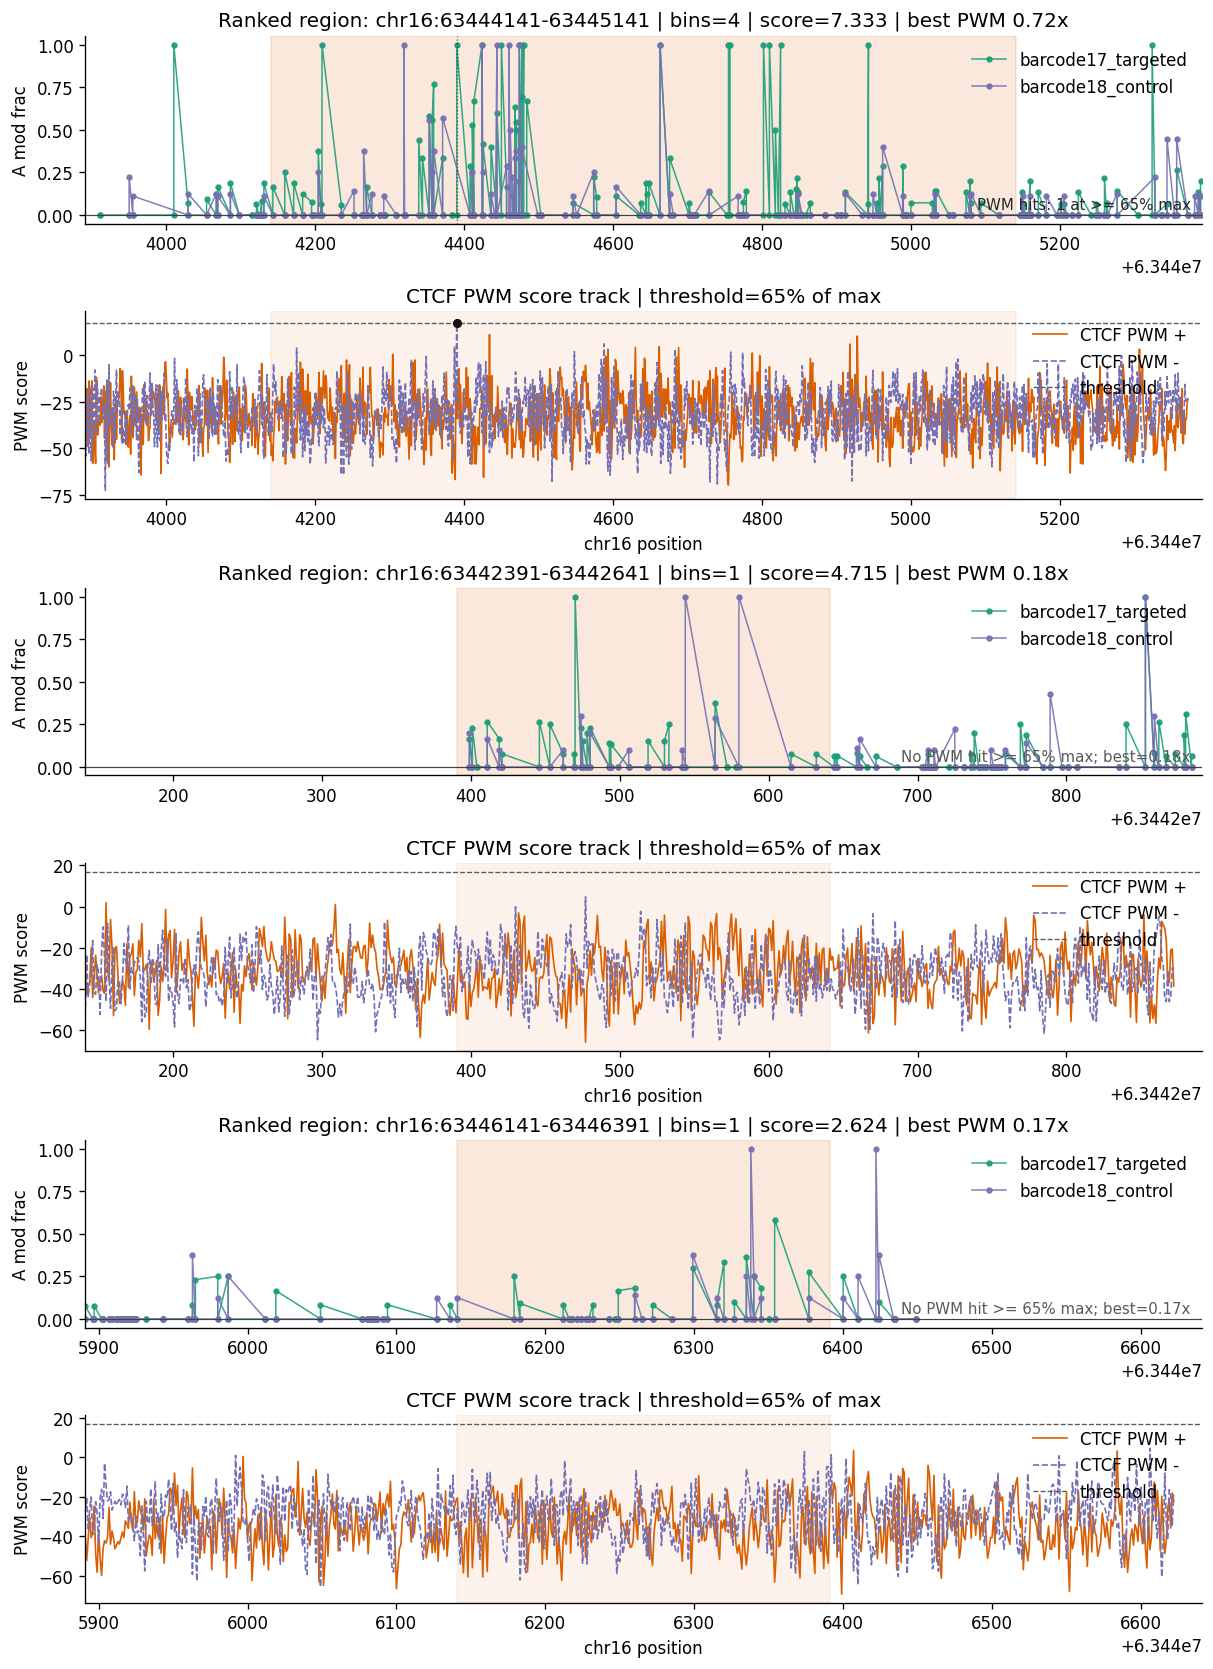

In [38]:
from collections import Counter
import pysam
from Bio import motifs
from Bio.Seq import Seq
from matplotlib.patches import Patch

zoom_flank = 250
ctcf_counts = {
    "A": [87, 167, 281, 56, 8, 744, 40, 107, 851, 5, 333, 54, 12, 56, 104, 372, 82, 117, 402],
    "C": [291, 145, 49, 800, 903, 13, 528, 433, 11, 0, 3, 12, 0, 8, 733, 13, 482, 322, 181],
    "G": [76, 414, 449, 21, 0, 65, 334, 48, 32, 903, 566, 504, 890, 775, 5, 507, 307, 73, 266],
    "T": [459, 187, 134, 36, 2, 91, 11, 324, 18, 3, 9, 341, 8, 71, 67, 17, 37, 396, 59],
}
ctcf_motif = motifs.Motif(alphabet="ACGT", counts=ctcf_counts)
ctcf_pwm = ctcf_motif.counts.normalize(pseudocounts=0.1)

_GENOME_BACKGROUND_CACHE: dict[str, dict[str, float]] = {}

def genome_background_from_fasta(fasta_path: Path) -> dict[str, float]:
    cache_key = str(fasta_path.resolve())
    if cache_key in _GENOME_BACKGROUND_CACHE:
        return _GENOME_BACKGROUND_CACHE[cache_key]
    counts = Counter()
    with pysam.FastaFile(str(fasta_path)) as fasta_bg:
        for contig in fasta_bg.references:
            seq = fasta_bg.fetch(contig).upper()
            counts.update(base for base in seq if base in "ACGT")
    total = sum(counts[base] for base in "ACGT")
    background = {base: counts[base] / total for base in "ACGT"}
    _GENOME_BACKGROUND_CACHE[cache_key] = background
    return background

ctcf_background = genome_background_from_fasta(ref_genome)
ctcf_pssm = ctcf_pwm.log_odds(ctcf_background)
ctcf_rpssm = ctcf_pwm.reverse_complement().log_odds(ctcf_background)
ctcf_pwm_threshold = ctcf_pssm.max * 0.65
sample_colors = {
    "barcode17_targeted": "#1B9E77",
    "barcode18_control": "#7570B3",
}

def _absolute_start(window_start: int, seq_len: int, pos: int) -> int:
    return window_start + pos if pos >= 0 else window_start + seq_len + pos

def _search_pwm(matrix, seq: str, *, window_start: int, threshold: float) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for pos, score in matrix.search(seq.upper(), threshold=threshold):
        rows.append(
            {
                "strand": "+" if int(pos) >= 0 else "-",
                "start": _absolute_start(window_start, len(seq), int(pos)),
                "end": _absolute_start(window_start, len(seq), int(pos)) + len(ctcf_motif),
                "score": float(score),
                "score_fraction": float(score) / float(ctcf_pssm.max),
            }
        )
    return pd.DataFrame(rows, columns=["strand", "start", "end", "score", "score_fraction"])

def find_ctcf_pwm_hits(seq: str, *, window_start: int) -> pd.DataFrame:
    hit_frames = [frame for frame in [_search_pwm(ctcf_pssm, seq, window_start=window_start, threshold=ctcf_pwm_threshold)] if not frame.empty]
    hits = pd.concat(hit_frames, ignore_index=True) if hit_frames else pd.DataFrame(columns=["strand", "start", "end", "score", "score_fraction"])
    if hits.empty:
        return hits
    return hits.sort_values(["score", "start"], ascending=[False, True]).reset_index(drop=True)

def best_ctcf_pwm_hit(seq: str, *, window_start: int) -> dict[str, object]:
    best_hit = {"strand": "+", "start": window_start, "end": window_start + len(ctcf_motif), "score": float("-inf"), "score_fraction": float("-inf")}
    for pos, score in ctcf_pssm.search(seq.upper(), threshold=ctcf_pssm.min):
        score_fraction = float(score) / float(ctcf_pssm.max)
        if float(score) > best_hit["score"]:
            start = _absolute_start(window_start, len(seq), int(pos))
            best_hit = {
                "strand": "+" if int(pos) >= 0 else "-",
                "start": start,
                "end": start + len(ctcf_motif),
                "score": float(score),
                "score_fraction": score_fraction,
            }
    return best_hit

fasta = pysam.FastaFile(str(ref_genome))
zoom_region_tables = []
n_zoom_regions = max(1, min(3, len(top_candidate_regions)))
fig, axes = plt.subplots(
    nrows=2 * n_zoom_regions,
    ncols=1,
    figsize=(10, 4.6 * n_zoom_regions),
    constrained_layout=True,
    sharex=False,
)
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

for region_rank, (plot_ax, pwm_ax, region) in enumerate(
    zip(axes[0::2], axes[1::2], top_candidate_regions.itertuples(index=False), strict=False),
    start=1,
):
    window_start = max(0, int(region.start) - zoom_flank)
    window_end = int(region.end) + zoom_flank
    window_seq = fasta.fetch(region.chrom, window_start, window_end)
    motif_hits = find_ctcf_pwm_hits(window_seq, window_start=window_start)
    best_hit = best_ctcf_pwm_hit(window_seq, window_start=window_start)
    if not motif_hits.empty:
        zoom_region_tables.append(
            motif_hits.assign(
                region_rank=region_rank,
                region=f"{region.chrom}:{region.start}-{region.end}",
            )
        )

    for sample_id, group in pileup_df.groupby("sample_id"):
        window = group.loc[
            (group["start"] >= window_start) & (group["start"] <= window_end)
        ].sort_values("start")
        plot_ax.plot(
            window["start"],
            window["mod_fraction"],
            marker="o",
            markersize=2.8,
            linewidth=0.9,
            color=sample_colors.get(sample_id, "0.35"),
            alpha=0.9,
            label=sample_id,
        )

    plot_ax.axvspan(int(region.start), int(region.end), color="#D95F02", alpha=0.14)
    plot_ax.axhline(0, color="0.25", linewidth=0.7)
    plot_ax.set_xlim(window_start, window_end)
    plot_ax.set_ylabel("A mod frac")
    plot_ax.set_title(
        f"Ranked region: {region.chrom}:{region.start}-{region.end} | bins={int(region.n_bins)} | score={region.max_score:.3f} | best PWM {best_hit['score_fraction']:.2f}x"
    )

    if motif_hits.empty:
        plot_ax.text(
            0.99,
            0.06,
            f"No PWM hit >= {ctcf_pwm_threshold / ctcf_pssm.max:.0%} max; best={best_hit['score_fraction']:.2f}x",
            transform=plot_ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color="0.35",
        )
    else:
        for _, hit in motif_hits.iterrows():
            plot_ax.axvline(hit["start"], color="0.15", linestyle=":", linewidth=0.8, alpha=0.7)
        plot_ax.text(
            0.99,
            0.06,
            f"PWM hits: {len(motif_hits)} at >= {ctcf_pwm_threshold / ctcf_pssm.max:.0%} max",
            transform=plot_ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color="0.15",
        )
    pwm_forward_scores = ctcf_pssm.calculate(window_seq.upper())
    pwm_reverse_scores = ctcf_rpssm.calculate(window_seq.upper())
    pwm_x = window_start + np.arange(len(pwm_forward_scores))
    pwm_ax.plot(pwm_x, pwm_forward_scores, color="#D95F02", linewidth=1.0, label="CTCF PWM +")
    pwm_ax.plot(pwm_x, pwm_reverse_scores, color="#7570B3", linewidth=1.0, linestyle="--", label="CTCF PWM -")
    pwm_ax.axhline(ctcf_pwm_threshold, color="0.35", linestyle="--", linewidth=0.8, label="threshold")
    for _, hit in motif_hits.iterrows():
        pwm_ax.scatter(
            hit["start"],
            ctcf_pwm_threshold,
            color="#111111",
            s=20,
            zorder=4,
        )
    pwm_ax.axvspan(int(region.start), int(region.end), color="#D95F02", alpha=0.08)
    pwm_ax.set_xlim(window_start, window_end)
    pwm_ax.set_ylabel("PWM score")
    pwm_ax.set_xlabel(f"{analysis_chrom} position")
    pwm_ax.set_title(
        f"CTCF PWM score track | threshold={ctcf_pwm_threshold / ctcf_pssm.max:.0%} of max"
    )
    pwm_ax.legend(frameon=False, loc="upper right")

    plot_ax.legend(frameon=False, loc="upper right")

zoom_motif_hits = pd.concat(zoom_region_tables, ignore_index=True) if zoom_region_tables else pd.DataFrame(columns=["strand", "start", "end", "score", "score_fraction", "region_rank", "region"])
display(zoom_motif_hits)
if not zoom_motif_hits.empty:
    print("CTCF motif hits found:", len(zoom_motif_hits))
else:
    print("CTCF motif hits found: 0")
plt.show()


## Multi-sample regional wrapper

With two samples, `run_dmr_multi` emits one pairwise regional BED. The value of this path is that the same call scales to more samples with the same `samples={name: pileup}` mapping.


In [19]:
multi_result = dmr.run_dmr_multi(
    samples={
        "barcode18_control": pileups["barcode18_control"],
        "barcode17_targeted": pileups["barcode17_targeted"],
    },
    regions_bed=region_bed,
    ref_genome=ref_genome,
    out_dir=OUT_DIR / "multi_A_chr16",
    bases=["A"],
    min_valid_coverage=1,
    threads=THREADS,
    prefix="barcode17_18_chr16_A",
)

display(multi_result.pair_files)


,pair_file,pair_name
0,/Users/ngamarra/Documents/GitHub/dimelo-toolkit/artifacts/dmr_barcode17_vs_18_notebook/multi_A_chr16/barcode17_18_chr16_A_barcode17_targeted_barcode18_control.bed,barcode17_18_chr16_A_barcode17_targeted_barcode18_control


## Output inventory

The notebook writes reusable bedMethyl pileups and DMR BED outputs under `artifacts/dmr_barcode17_vs_18_notebook/`. The important files are:

- `barcode17_targeted_chr16_A/pileup.sorted.bed.gz`: targeted-sample bedMethyl pileup
- `barcode18_control_chr16_A/pileup.sorted.bed.gz`: control-sample bedMethyl pileup
- `barcode17_targeted_vs_barcode18_control.A.regional.bed`: regional DMR table
- `multi_A_chr16/`: multi-sample DMR outputs


In [21]:
outputs = [
    OUT_DIR / "chr16_ctcf_demo_regions.bed",
    OUT_DIR / "barcode17_targeted_chr16_A/pileup.sorted.bed.gz",
    OUT_DIR / "barcode18_control_chr16_A/pileup.sorted.bed.gz",
    OUT_DIR / "barcode17_targeted_vs_barcode18_control.A.regional.bed",
    OUT_DIR / "multi_A_chr16/",
]
display(pd.DataFrame({"path": [str(path) for path in outputs], "size_kb": [round(path.stat().st_size / 1024, 1) if path.is_file() else None for path in outputs]}))


,path,size_kb
0,artifacts/dmr_barcode17_vs_18_notebook/chr16_ctcf_demo_regions.bed,0.1
1,artifacts/dmr_barcode17_vs_18_notebook/barcode17_targeted_chr16_A/pileup.sorted.bed.gz,9.4
2,artifacts/dmr_barcode17_vs_18_notebook/barcode18_control_chr16_A/pileup.sorted.bed.gz,7.3
3,artifacts/dmr_barcode17_vs_18_notebook/barcode17_targeted_vs_barcode18_control.A.regional.bed,0.7
4,artifacts/dmr_barcode17_vs_18_notebook/multi_A_chr16,NaN


## PWM score and significance association

This section keeps the analysis restricted to positive-effect 100 bp bins only. It checks whether stronger CTCF PWM matches track with larger DMR effect sizes, whether PWM hits are enriched among significant positive bins, and how the same relationship looks in each of the top 3 candidate regions.


In [ ]:
from scipy.stats import fisher_exact, spearmanr

positive_bins = tiled.loc[tiled["effect_size"] > 0].copy().reset_index(drop=True)
bin_score_rows = []
for row in positive_bins.itertuples(index=False):
    seq = fasta.fetch(row.chrom, int(row.start), int(row.end))
    best_hit = best_ctcf_pwm_hit(seq, window_start=int(row.start))
    bin_score_rows.append(
        {
            "chrom": row.chrom,
            "start": int(row.start),
            "end": int(row.end),
            "ctcf_best_score": best_hit["score"],
            "ctcf_best_score_fraction": best_hit["score_fraction"],
            "ctcf_best_hit_start": best_hit["start"],
            "ctcf_best_hit_end": best_hit["end"],
            "ctcf_best_hit_strand": best_hit["strand"],
        }
    )

score_df = pd.DataFrame(bin_score_rows)
positive_bins = positive_bins.merge(score_df, on=["chrom", "start", "end"], how="left")
positive_bins["ctcf_best_score_fraction"] = positive_bins["ctcf_best_score_fraction"].fillna(0.0)
positive_bins["ctcf_hit_above_threshold"] = (
    positive_bins["ctcf_best_score"] >= ctcf_pwm_threshold
).fillna(False)

if len(positive_bins) >= 2 and positive_bins["ctcf_best_score_fraction"].nunique() > 1:
    spearman_rho, spearman_p = spearmanr(
        positive_bins["ctcf_best_score_fraction"],
        positive_bins["effect_size"],
    )
else:
    spearman_rho, spearman_p = np.nan, np.nan

contingency = pd.crosstab(
    positive_bins["candidate_dmr"],
    positive_bins["ctcf_hit_above_threshold"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)
odds_ratio, fisher_p = fisher_exact(contingency.to_numpy(), alternative="greater")

association_summary = pd.DataFrame(
    {
        "metric": [
            "positive bins",
            "significant positive bins",
            "PWM-hit positive bins",
            "PWM-hit significant positive bins",
            "Spearman rho",
            "Spearman p-value",
            "Fisher odds ratio",
            "Fisher p-value",
        ],
        "value": [
            int(len(positive_bins)),
            int(positive_bins["candidate_dmr"].sum()),
            int(positive_bins["ctcf_hit_above_threshold"].sum()),
            int((positive_bins["candidate_dmr"] & positive_bins["ctcf_hit_above_threshold"]).sum()),
            spearman_rho,
            spearman_p,
            odds_ratio,
            fisher_p,
        ],
    }
)

display(association_summary)
display(positive_bins[[
    "chrom", "start", "end", "effect_size", "score", "ctcf_best_score_fraction",
    "ctcf_hit_above_threshold", "candidate_dmr"
]].sort_values(["candidate_dmr", "ctcf_best_score_fraction"], ascending=[False, False]))


In [ ]:
fig, (scatter_ax, enrich_ax) = plt.subplots(
    ncols=2,
    figsize=(11.5, 4.2),
    constrained_layout=True,
)

non_sig = positive_bins.loc[~positive_bins["candidate_dmr"]]
sig = positive_bins.loc[positive_bins["candidate_dmr"]]
scatter_ax.scatter(
    non_sig["ctcf_best_score_fraction"],
    non_sig["effect_size"],
    s=28,
    color="#7570B3",
    alpha=0.8,
    label="positive non-significant bin",
)
scatter_ax.scatter(
    sig["ctcf_best_score_fraction"],
    sig["effect_size"],
    s=34,
    color="#D95F02",
    alpha=0.95,
    label="significant positive bin",
)
hit_bins = positive_bins.loc[positive_bins["ctcf_hit_above_threshold"]]
if not hit_bins.empty:
    scatter_ax.scatter(
        hit_bins["ctcf_best_score_fraction"],
        hit_bins["effect_size"],
        s=72,
        facecolors="none",
        edgecolors="#111111",
        linewidths=1.1,
        label="PWM-hit bin",
    )
scatter_ax.axhline(ABS_EFFECT_MIN, color="0.65", linestyle="--", linewidth=0.8)
scatter_ax.axvline(ctcf_pwm_threshold / ctcf_pssm.max, color="0.65", linestyle="--", linewidth=0.8)
scatter_ax.set_xlabel("Best CTCF PWM score fraction")
scatter_ax.set_ylabel("Effect size (barcode17 - barcode18)")
scatter_ax.set_title(
    f"Positive bins only: Spearman rho={spearman_rho:.2f}, p={spearman_p:.3g}"
)
scatter_ax.legend(frameon=False, loc="best")

hit_rate = pd.DataFrame(
    {
        "category": ["non-significant", "significant"],
        "hit_rate": [
            float(non_sig["ctcf_hit_above_threshold"].mean()) if len(non_sig) else 0.0,
            float(sig["ctcf_hit_above_threshold"].mean()) if len(sig) else 0.0,
        ],
    }
)
enrich_ax.bar(hit_rate["category"], hit_rate["hit_rate"], color=["#7570B3", "#D95F02"])
enrich_ax.set_ylim(0, 1)
enrich_ax.set_ylabel("Fraction with PWM hit")
enrich_ax.set_title(
    f"Enrichment: OR={odds_ratio:.2f}, Fisher p={fisher_p:.3g}"
)
for idx, value in enumerate(hit_rate["hit_rate"]):
    enrich_ax.text(idx, value + 0.03, f"{value:.0%}", ha="center", va="bottom", fontsize=9)
plt.show()


In [ ]:
fig, axes = plt.subplots(
    nrows=len(top_candidate_regions),
    ncols=1,
    figsize=(8.8, 3.4 * len(top_candidate_regions)),
    constrained_layout=True,
)
if len(top_candidate_regions) == 1:
    axes = [axes]

for ax, region in zip(axes, top_candidate_regions.itertuples(index=False), strict=False):
    window_start = max(0, int(region.start) - zoom_flank)
    window_end = int(region.end) + zoom_flank
    local_bins = positive_bins.loc[(positive_bins["start"] < window_end) & (positive_bins["end"] > window_start)].copy()
    if len(local_bins) >= 2 and local_bins["ctcf_best_score_fraction"].nunique() > 1:
        local_rho, local_p = spearmanr(
            local_bins["ctcf_best_score_fraction"],
            local_bins["effect_size"],
        )
    else:
        local_rho, local_p = np.nan, np.nan

    local_non_sig = local_bins.loc[~local_bins["candidate_dmr"]]
    local_sig = local_bins.loc[local_bins["candidate_dmr"]]
    ax.scatter(
        local_non_sig["ctcf_best_score_fraction"],
        local_non_sig["effect_size"],
        s=26,
        color="#7570B3",
        alpha=0.8,
        label="positive non-significant bin",
    )
    ax.scatter(
        local_sig["ctcf_best_score_fraction"],
        local_sig["effect_size"],
        s=34,
        color="#D95F02",
        alpha=0.95,
        label="significant positive bin",
    )
    local_hits = local_bins.loc[local_bins["ctcf_hit_above_threshold"]]
    if not local_hits.empty:
        ax.scatter(
            local_hits["ctcf_best_score_fraction"],
            local_hits["effect_size"],
            s=84,
            facecolors="none",
            edgecolors="#111111",
            linewidths=1.2,
            label="PWM-hit bin",
        )
        for _, hit in local_hits.iterrows():
            ax.annotate(
                f"{int(hit['start'])}-{int(hit['end'])}",
                (hit["ctcf_best_score_fraction"], hit["effect_size"]),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=8,
            )
    ax.axvline(ctcf_pwm_threshold / ctcf_pssm.max, color="0.5", linestyle="--", linewidth=0.8)
    ax.axhline(ABS_EFFECT_MIN, color="0.65", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Best CTCF PWM score fraction")
    ax.set_ylabel("Effect size")
    ax.set_title(
        f"{region.chrom}:{region.start}-{region.end} | rho={local_rho:.2f}, p={local_p:.3g}, n={len(local_bins)}"
    )
    ax.legend(frameon=False, loc="best")
plt.show()
